**Objective**
To build a Convoultinal Autoencoder that compress facial images into lower-dimensional latent representation and recounstrus them with minimal loss of information

**Purpose**
A Convolutinoal Autoencoder is an unsupervised deep learning model used for:
Iamge Compression Image recostruction Feature Extraction Dimenstinality Reduction
The encoder learns a compressed represetntation,While the decoder reconstructs the original image from this compressed representation

In [ ]:
import os
import shutil #moving files copying files
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import pandas as pd
from tensorflow.keras.layers import (
    BatchNormalization,
    Dropout,
    ReLU
)

In [ ]:
!pip install -q kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
# create a smaller Dataset
source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for img in images:
  shutil.copy(
    os.path.join(source_folder,img),
    destination_folder)
print("copied", len(images),"images")

copied 5000 images


In [ ]:
IMAGE_SIZE =(64,64)# data preprocessing
BATCH_SIZE = 32

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


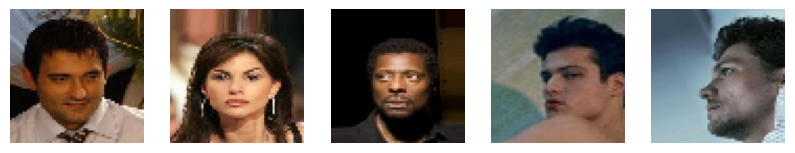

In [ ]:
images,_ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()


In [ ]:
input_img = Input(shape=(64,64,3))
x = Conv2D(32,(3,3),
           activation="relu",padding="same")(input_img)
x = MaxPooling2D((2,2),
                 padding="same")(x)
x = Conv2D(
    64,
     (3,3),

    activation="relu",
    padding="same")(x)
encoded = MaxPooling2D(
    (2,2),
    padding="same")(x)
x = Conv2D(
    215,
    (3,3),
    activation="relu",
    padding="same")(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(
    215,
    (3,3),
    activation="relu",
    padding="same")(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3,
                 (3,3),
                 activation="sigmoid",
                 padding="same"
                 )(x)

In [ ]:
#create model
autoencoder = Model(input_img,decoded)

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


In [ ]:
autoencoder.summary()#model summary

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 215)    │       124,055 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 215)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 215)    │       416,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 215)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │         5,808 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565,495 (2.16 MB)

 Trainable params: 565,495 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 0.0182 - val_loss: 0.0072
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0066 - val_loss: 0.0058
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0057 - val_loss: 0.0060
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0043 - val_loss: 0.0040
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0037 - val_loss: 0.0034
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0034 - val_loss: 0.0037
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_1073/1291168656.py:8: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend("training","validation")


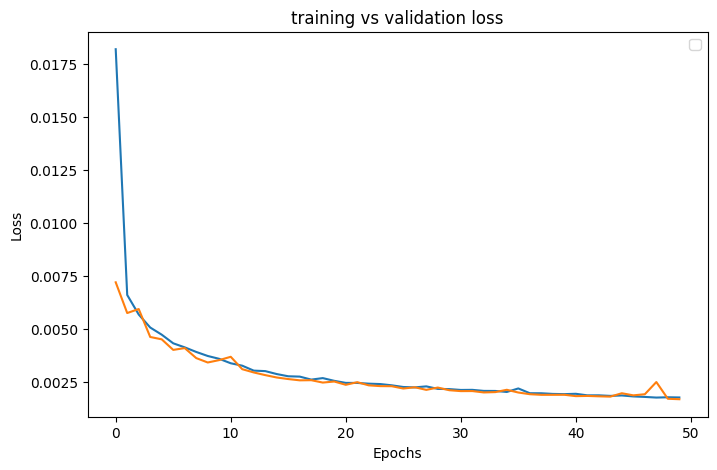

In [ ]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("training vs validation loss")
plt.legend("training","validation")
plt.show()


In [ ]:
#evaluate model
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0017
Validation Loss: 0.0016958726337179542


In [ ]:
images,_=next(validation_generator)
reconstructed_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step


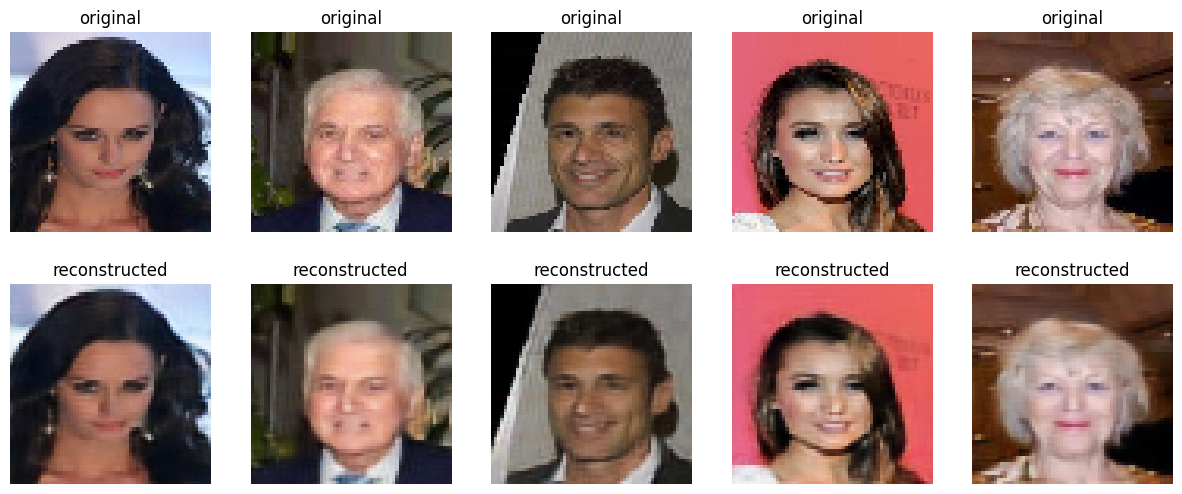

In [ ]:
#display results
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("original")
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed_images[i])
  plt.title("reconstructed")
  plt.axis("off")
plt.show()